In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from transformers import CLIPVisionModel, CLIPImageProcessor

# --- find project root (same pattern as other notebooks) ---

def find_project_root(start: Path) -> Path:
    """
    Walk upwards from `start` until we find a directory that has 'src' and 'data'.
    """
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

cwd = Path.cwd()
project_root = find_project_root(cwd)
print("CWD         :", cwd)
print("PROJECT_ROOT:", project_root)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
print("project_root in sys.path:", str(project_root) in sys.path)

# --- imports from your code ---

from src.clip_domain_datasets import ClipDomainDataset, clip_collate_fn

# --- paths ---

META_DIR = project_root / "data" / "processed" / "metadata"
CSV_PATH = META_DIR / "domain_classification_sentences.csv"

CKPT_CLIP_BASELINE = project_root / "checkpoints" / "clip_domain_baseline_clip.pt"
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

print("\nCSV_PATH           :", CSV_PATH)
print("CKPT_CLIP_BASELINE :", CKPT_CLIP_BASELINE)

# quick CSV sanity
df = pd.read_csv(CSV_PATH)
print("\nCSV shape:", df.shape)
print("hf_split values:", df["hf_split"].unique())
print("domain_label counts:\n", df["domain_label"].value_counts())

# --- device ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# --- model wrapper (same structure as in training script) ---

class ClipDomainClassifier(nn.Module):
    """
    CLIP vision encoder + small classifier head.
    Same as in train_clip_domain_classifier_baseline.py.
    """

    def __init__(self, clip_vision: CLIPVisionModel, hidden_size: int, num_classes: int = 2):
        super().__init__()
        self.clip_vision = clip_vision
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        outputs = self.clip_vision(pixel_values=pixel_values)
        feats = outputs.pooler_output  # (B, hidden_size)
        logits = self.classifier(feats)
        return logits


/home/woody/iwi5/iwi5384h/software/private/conda/envs/emuru/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CWD         : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/notebooks
PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
project_root in sys.path: True

CSV_PATH           : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/domain_classification_sentences.csv
CKPT_CLIP_BASELINE : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/checkpoints/clip_domain_baseline_clip.pt

CSV shape: (19602, 7)
hf_split values: ['test' 'train' 'validation']
domain_label counts:
 domain_label
0    9801
1    9801
Name: count, dtype: int64

Using device: cpu


In [2]:
# Load CLIP processor + vision backbone
print(f"Loading CLIP vision model: {CLIP_MODEL_NAME}")
clip_processor = CLIPImageProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_vision = CLIPVisionModel.from_pretrained(CLIP_MODEL_NAME).to(device)

# Freeze CLIP vision (as during training)
for p in clip_vision.parameters():
    p.requires_grad = False

hidden_size = clip_vision.config.hidden_size
print("CLIP hidden_size:", hidden_size)

# Build test dataset / loader (baseline CSV)
test_ds_clip = ClipDomainDataset(
    csv_path=CSV_PATH,
    project_root=project_root,
    split="test",
    clip_processor=clip_processor,
)

test_loader_clip = DataLoader(
    test_ds_clip,
    batch_size=64,
    shuffle=False,
    collate_fn=clip_collate_fn,
)

# Instantiate classifier and load state_dict
model_clip = ClipDomainClassifier(
    clip_vision=clip_vision,
    hidden_size=hidden_size,
    num_classes=2,
).to(device)

print("\nModel:", model_clip.__class__.__name__)

if CKPT_CLIP_BASELINE.exists():
    state = torch.load(CKPT_CLIP_BASELINE, map_location=device)
    model_clip.load_state_dict(state)
    print("Loaded baseline CLIP checkpoint from:", CKPT_CLIP_BASELINE)
else:
    print("WARNING: CLIP baseline checkpoint not found, using random weights!")

model_clip.eval()


Loading CLIP vision model: openai/clip-vit-base-patch32
CLIP hidden_size: 768
ClipDomainDataset: 5506 samples (csv='domain_classification_sentences.csv', split='test')

Model: ClipDomainClassifier
Loaded baseline CLIP checkpoint from: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/checkpoints/clip_domain_baseline_clip.pt


ClipDomainClassifier(
  (clip_vision): CLIPVisionModel(
    (vision_model): CLIPVisionTransformer(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
        (position_embedding): Embedding(50, 768)
      )
      (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
      

In [3]:
all_true = []
all_pred = []
all_prob_fake = []  # probability for class 1 (Emuru/fake)
all_sources = []
all_idxs = []
all_texts = []

criterion = nn.CrossEntropyLoss()

model_clip.eval()

with torch.no_grad():
    total_loss = 0.0
    total_samples = 0

    for batch in test_loader_clip:
        pixel_values = batch["pixel_values"].to(device)  # (B, 3, H, W)
        labels = batch["labels"].to(device)              # (B,)

        logits = model_clip(pixel_values)                # (B, 2)
        loss = criterion(logits, labels)

        probs = F.softmax(logits, dim=1)
        pred = logits.argmax(dim=1)

        total_loss += loss.item() * pixel_values.size(0)
        total_samples += pixel_values.size(0)

        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob_fake.extend(probs[:, 1].cpu().numpy().tolist())

        all_sources.extend(batch["sources"])
        all_idxs.extend(batch["idxs"])
        all_texts.extend(batch["texts"])

test_loss = total_loss / total_samples
test_acc = (np.array(all_true) == np.array(all_pred)).mean()

# Build DataFrame
test_results_clip = pd.DataFrame({
    "true_label": all_true,
    "pred_label": all_pred,
    "prob_fake": all_prob_fake,
    "source": all_sources,
    "idx": all_idxs,
    "text": all_texts,
})

print("test_results_clip shape:", test_results_clip.shape)
display(test_results_clip.head())

print(f"\nCLIP baseline test loss: {test_loss:.4f}")
print(f"CLIP baseline test accuracy: {test_acc*100:.2f}%")


test_results_clip shape: (5506, 6)


,true_label,pred_label,prob_fake,source,idx,text
0,0,0,2.944852e-06,iam,7957,commerce may be kept going - though if ever
1,0,0,2.410758e-05,iam,9341,"' Be silent , woman , and listen , ' Band Appa..."
2,1,1,9.999992e-01,emuru,8143,"Easterly winds , on the other hand ,"
3,1,1,9.963755e-01,emuru,10368,"just dusty-grey but muddy , slimy even ."
4,0,0,3.306166e-07,iam,8651,needed taxation in order to supplement



CLIP baseline test loss: 0.0012
CLIP baseline test accuracy: 99.96%


In [4]:
num_classes = 2
cm_clip = np.zeros((num_classes, num_classes), dtype=int)

for t, p in zip(test_results_clip["true_label"], test_results_clip["pred_label"]):
    cm_clip[t, p] += 1

print("Confusion matrix (CLIP baseline; rows = true, cols = pred):")
print("       pred=0    pred=1")
print(f"true=0   {cm_clip[0,0]:6d}   {cm_clip[0,1]:6d}")
print(f"true=1   {cm_clip[1,0]:6d}   {cm_clip[1,1]:6d}")

acc_iam_clip   = cm_clip[0,0] / cm_clip[0].sum() if cm_clip[0].sum() > 0 else 0.0
acc_emuru_clip = cm_clip[1,1] / cm_clip[1].sum() if cm_clip[1].sum() > 0 else 0.0

print("\nPer-class accuracy (CLIP baseline):")
print(f"  Class 0 (IAM / genuine): {acc_iam_clip*100:.2f}%")
print(f"  Class 1 (Emuru / fake) : {acc_emuru_clip*100:.2f}%")


Confusion matrix (CLIP baseline; rows = true, cols = pred):
       pred=0    pred=1
true=0     2752        1
true=1        1     2752

Per-class accuracy (CLIP baseline):
  Class 0 (IAM / genuine): 99.96%
  Class 1 (Emuru / fake) : 99.96%


Number of misclassified test samples (CLIP baseline): 2
Misclassified merged shape: (2, 8)

Rows to show: 2
idx: 10200 | source: emuru
text: 'he shrugged diffidently , " I like the work . One gets plenty'
true_label    : 1 (0=IAM/genuine, 1=Emuru/fake)
pred_label    : 0
prob_fake (p(class=1)) = 0.4597
filepath: data/raw/emuru/sentences/iam_10200_sentence.png


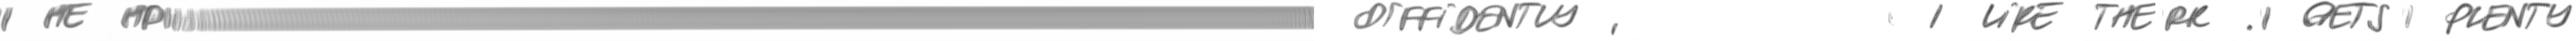

idx: 10116 | source: iam
text: '-----------------------------------------------------'
true_label    : 0 (0=IAM/genuine, 1=Emuru/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.8120
filepath: data/raw/iam/iam_10116.png


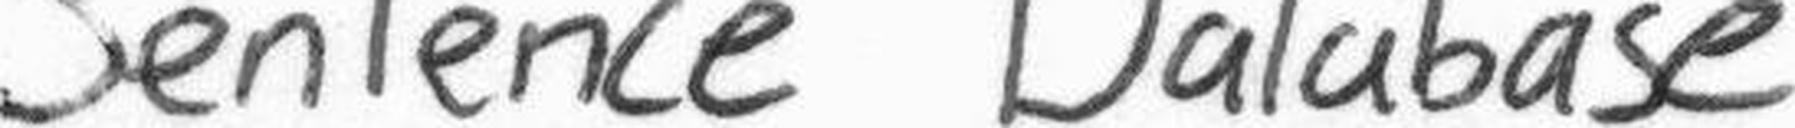

In [5]:
from IPython.display import display
from PIL import Image

# Misclassified examples
mis_clip = test_results_clip[test_results_clip["true_label"] != test_results_clip["pred_label"]].copy()
print("Number of misclassified test samples (CLIP baseline):", len(mis_clip))

# Restrict original df to test split
df_test = df[df["hf_split"] == "test"].copy()

# Merge to get filepath
mis_merged_clip = mis_clip.merge(
    df_test[["idx", "source", "filepath", "domain_label"]],
    on=["idx", "source"],
    how="left",
    suffixes=("", "_orig"),
)

print("Misclassified merged shape:", mis_merged_clip.shape)

if len(mis_merged_clip) == 0:
    print("\nNo misclassifications for CLIP baseline 🎉")
    print("Showing borderline examples instead.")
    # borderline = closest to prob_fake = 0.5
    test_results_clip["dist_to_0_5"] = (test_results_clip["prob_fake"] - 0.5).abs()
    rows_to_show = test_results_clip.sort_values("dist_to_0_5").head(8).merge(
        df_test[["idx", "source", "filepath", "domain_label"]],
        on=["idx", "source"],
        how="left",
        suffixes=("", "_orig"),
    )
else:
    rows_to_show = mis_merged_clip.head(8)

print("\nRows to show:", len(rows_to_show))

for i, row in rows_to_show.iterrows():
    print("=" * 80)
    print(f"idx: {row['idx']} | source: {row['source']}")
    print(f"text: {repr(row['text'])}")
    print(f"true_label    : {row['true_label']} (0=IAM/genuine, 1=Emuru/fake)")
    print(f"pred_label    : {row['pred_label']}")
    print(f"prob_fake (p(class=1)) = {row['prob_fake']:.4f}")
    print(f"filepath: {row['filepath']}")

    img_path = project_root / row["filepath"]

    try:
        img = Image.open(img_path).convert("L")
        display(img)
    except Exception as e:
        print("  Could not load/display image:", e)


Using N = 1500 points for t-SNE
Feature matrix shape: (1500, 768)
t-SNE embedding shape: (1500, 2)


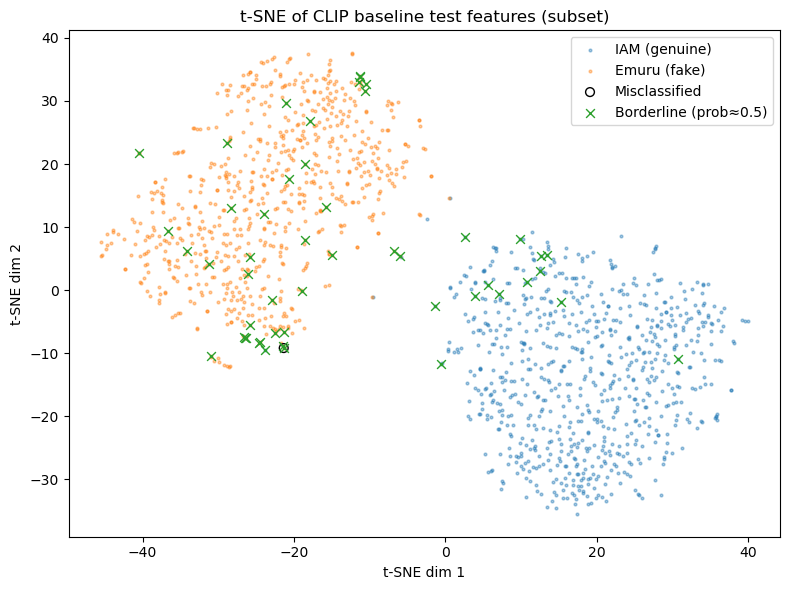

In [6]:
from sklearn.manifold import TSNE

# Limit how many test samples we use for t-SNE
MAX_POINTS = 1500  # adjust as needed

all_feats = []
all_true = []
all_pred = []
all_prob_fake = []
all_sources = []
all_idxs = []
all_texts = []

model_clip.eval()
with torch.no_grad():
    for batch in test_loader_clip:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"]
        sources = batch["sources"]
        idxs = batch["idxs"]
        texts = batch["texts"]

        logits = model_clip(pixel_values)
        probs = F.softmax(logits, dim=1)
        pred = logits.argmax(dim=1)

        # features from CLIP vision encoder
        outputs = model_clip.clip_vision(pixel_values=pixel_values)
        feats = outputs.pooler_output  # (B, hidden_size)

        all_feats.append(feats.cpu().numpy())
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob_fake.extend(probs[:, 1].cpu().numpy().tolist())
        all_sources.extend(sources)
        all_idxs.extend(idxs)
        all_texts.extend(texts)

        if len(all_true) >= MAX_POINTS:
            break

# Stack and truncate
X = np.concatenate(all_feats, axis=0)
N = min(len(all_true), MAX_POINTS)
X = X[:N]
y_true = np.array(all_true[:N])
y_pred = np.array(all_pred[:N])
prob_fake = np.array(all_prob_fake[:N])
sources_sub = all_sources[:N]
idxs_sub = all_idxs[:N]
texts_sub = all_texts[:N]

print("Using N =", N, "points for t-SNE")
print("Feature matrix shape:", X.shape)

# t-SNE to 2D
tsne = TSNE(
    n_components=2,
    init="random",
    learning_rate="auto",
    random_state=42,
    perplexity=30,
)
X_emb = tsne.fit_transform(X)
print("t-SNE embedding shape:", X_emb.shape)

# Build DataFrame for convenience
vis_df_clip = pd.DataFrame({
    "true_label": y_true,
    "pred_label": y_pred,
    "prob_fake": prob_fake,
    "source": sources_sub,
    "idx": idxs_sub,
    "text": texts_sub,
})

# Misclassified & borderline masks
mis_mask = (vis_df_clip["true_label"] != vis_df_clip["pred_label"]).to_numpy()

vis_df_clip["dist_to_0_5"] = (vis_df_clip["prob_fake"] - 0.5).abs()
borderline_idx = vis_df_clip["dist_to_0_5"].nsmallest(50).index
borderline_mask = np.zeros(len(vis_df_clip), dtype=bool)
borderline_mask[borderline_idx.to_numpy()] = True

iam_mask = (vis_df_clip["true_label"].to_numpy() == 0)
emu_mask = (vis_df_clip["true_label"].to_numpy() == 1)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_emb[iam_mask, 0],
    X_emb[iam_mask, 1],
    s=4,
    alpha=0.4,
    label="IAM (genuine)",
)
plt.scatter(
    X_emb[emu_mask, 0],
    X_emb[emu_mask, 1],
    s=4,
    alpha=0.4,
    label="Emuru (fake)",
)

if mis_mask.any():
    plt.scatter(
        X_emb[mis_mask, 0],
        X_emb[mis_mask, 1],
        s=40,
        edgecolors="k",
        facecolors="none",
        linewidths=1.0,
        label="Misclassified",
    )

plt.scatter(
    X_emb[borderline_mask, 0],
    X_emb[borderline_mask, 1],
    s=40,
    marker="x",
    linewidths=1.0,
    label="Borderline (prob≈0.5)",
)

plt.title("t-SNE of CLIP baseline test features (subset)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.tight_layout()
plt.show()
